# NYC Taxi Fare Prediction  
### End-to-End Machine Learning Mini Project

**NAME:**HAIDER ALI
**REGISTRATINO_NO:**23PWDSC0123
**DEPARTMENT:**DATA SCIENCE
**SEMESTER:**5TH
**Course:**Applied_Data_Science (Fall 2025)  
**Assignment:** Mini Project (Assignment No. 02)  
**Objective:** Predict taxi fare amounts using real-world NYC taxi trip data by following an end-to-end machine learning workflow.


## Project Overview

This mini project focuses on building a complete end-to-end machine learning pipeline to predict taxi fare amounts in New York City.
The project includes data loading,
cleaning, feature engineering, exploratory data analysis (EDA), model training, evaluation, and interpretation.

Predicting taxi fares is a real-world regression problem that has practical applications in ride-hailing services, fare estimation systems,
and transportation analytics. The target variable in this project is `fare_amount`.


## 1. Introduction

### Problem Statement
New York City taxi services generate millions of trips every year, and accurately predicting taxi fares is essential for both service providers and passengers.
Fare estimation depends on multiple factors such as trip distance, pickup and drop-off locations, time of travel, and passenger count.
Manually estimating fares without a data-driven approach can lead to inaccuracies and inefficiencies.

### Objective
The objective of this project is to build an end-to-end machine learning model that predicts the **fare amount** of a NYC taxi trip using historical trip data.
This includes implementing data cleaning, feature engineering, exploratory data analysis, and training regression models to learn patterns in the data.

### Real-World Importance
Accurate taxi fare prediction has practical importance in:
- Ride-hailing applications for upfront fare estimation
- Reducing fare disputes between drivers and passengers
- Transportation planning and demand analysis
- Improving customer experience through transparency and trust




#Data Loading & Initial Exploration

In [1]:
# Basic numerical and data handling libraries
import numpy as np
import pandas as pd

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [3]:
# Load the dataset
df = pd.read_csv("nyc_taxi_data.csv")

# Display first 5 rows
df.head()


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,26:21.0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,52:16.0,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,35:00.0,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,30:42.0,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,51:00.0,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [4]:
# Check dataset shape
df.shape


(50000, 8)

In [5]:
# Inspect data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                50000 non-null  object 
 1   fare_amount        50000 non-null  float64
 2   pickup_datetime    50000 non-null  object 
 3   pickup_longitude   50000 non-null  float64
 4   pickup_latitude    50000 non-null  float64
 5   dropoff_longitude  50000 non-null  float64
 6   dropoff_latitude   50000 non-null  float64
 7   passenger_count    50000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 3.1+ MB


In [6]:
# Statistical summary of numerical features
df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,11.364171,-72.509756,39.933759,-72.504616,39.926251,1.667840
std,9.685557,10.393860,6.224857,10.407570,6.014737,1.289195
min,-5.000000,-75.423848,-74.006893,-84.654241,-74.006377,0.000000
25%,6.000000,-73.992062,40.734880,-73.991152,40.734372,1.000000
50%,8.500000,-73.981840,40.752678,-73.980082,40.753372,1.000000
75%,12.500000,-73.967148,40.767360,-73.963584,40.768167,2.000000
max,200.000000,40.783472,401.083332,40.851027,43.415190,6.000000


#Data Cleaning

Real-world datasets often contain missing values, incorrect records, and outliers that can negatively impact model performance.
In this step, we clean the NYC Taxi dataset by removing or correcting invalid observations.

The goal of data cleaning is to ensure that the data used for modeling is realistic, consistent, and reliable.


In [7]:
# Check for missing values
df.isnull().sum()


,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


In [8]:
# Drop rows with missing values
df = df.dropna()

# Check shape after dropping missing values
df.shape


(50000, 8)

### Removing Invalid Fare Amounts

Taxi fares cannot be zero or negative. Such values are invalid and may result from data recording errors.
We filter out trips with fare amounts less than or equal to zero.


In [9]:
# Remove trips with non-positive fare amounts
df = df[df["fare_amount"] > 0]

df.shape


(49991, 8)

### Cleaning Passenger Count

Passenger count must be a reasonable positive number. Trips with zero or excessively high passenger counts
are unrealistic and can distort model learning.


In [10]:
# Keep trips with realistic passenger counts
df = df[(df["passenger_count"] > 0) & (df["passenger_count"] <= 6)]

df.shape


(49826, 8)

### Datetime Conversion

Datetime values are converted to a proper datetime format to enable extraction of useful time-based features
such as hour, day, month, and year in later steps.


In [16]:
# Convert pickup datetime column to datetime format
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])


## Feature Engineering

Feature engineering involves transforming raw data into meaningful features that help machine learning models
better understand underlying patterns.

In taxi fare prediction, the fare is strongly influenced by:
- Distance traveled
- Time of travel
- Traffic patterns related to hour and day

Therefore, we engineer distance-based and time-based features to improve predictive performance.


In [12]:
import math

# Function to calculate Haversine distance (in kilometers)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in kilometers

    lat1, lon1, lat2, lon2 = map(
        math.radians, [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        math.sin(dlat / 2)**2 +
        math.cos(lat1) * math.cos(lat2) *
        math.sin(dlon / 2)**2
    )

    c = 2 * math.asin(math.sqrt(a))

    return R * c


### Why Use Haversine Distance?

Taxi fare depends on the actual distance traveled between pickup and drop-off locations.
The Haversine formula calculates the great-circle distance between two points on the Earth,
providing a more accurate distance measure than simple Euclidean distance.


In [14]:
# Apply Haversine distance to dataset
df["trip_distance_km"] = df.apply(
    lambda row: haversine_distance(
        row["pickup_latitude"],
        row["pickup_longitude"],
        row["dropoff_latitude"],
        row["dropoff_longitude"]
    ),
    axis=1
)

df[["trip_distance_km"]].head()


,trip_distance_km
0,1.030764
1,8.450134
2,1.389525
3,2.799270
4,1.999157


### Time-Based Feature Extraction

Time-related patterns such as rush hours, weekends, and seasonal variations
can significantly influence taxi fares. We extract useful components from the pickup datetime.


In [17]:

# Extract time-based features
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_day"] = df["pickup_datetime"].dt.day
df["pickup_month"] = df["pickup_datetime"].dt.month
df["pickup_year"] = df["pickup_datetime"].dt.year
df["pickup_weekday"] = df["pickup_datetime"].dt.weekday

df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance_km,pickup_hour,pickup_day,pickup_month,pickup_year,pickup_weekday
0,26:21.0,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,1.030764,17,15,6,2009,0
1,52:16.0,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,8.450134,16,5,1,2010,1
2,35:00.0,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,1.389525,0,18,8,2011,3
3,30:42.0,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,2.799270,4,21,4,2012,5
4,51:00.0,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,1.999157,7,9,3,2010,1


## 5. Train–Test Split (Time-Aware)

In time-dependent datasets such as taxi trips, future data should never be used to predict past events.
A random train-test split can cause data leakage, where information from future trips leaks into the training process.

To avoid this, we perform a **time-aware split**, where:
- The model is trained on earlier trips
- The model is tested on later trips

This approach more accurately reflects real-world deployment scenarios.


In [18]:
# Sort dataset by pickup datetime
df = df.sort_values("pickup_datetime")

df.head()


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance_km,pickup_hour,pickup_day,pickup_month,pickup_year,pickup_weekday
12739,31:49.0,8.6,2009-01-01 01:31:49+00:00,-73.994192,40.720077,-73.993356,40.742642,1,2.510102,1,1,1,2009,3
17546,05:37.0,11.0,2009-01-01 02:05:37+00:00,-73.978433,40.744781,-74.004713,40.734328,1,2.500651,2,1,1,2009,3
25687,07:49.0,17.8,2009-01-01 02:07:49+00:00,-73.984291,40.667851,-74.006015,40.735481,3,7.739881,2,1,1,2009,3
8684,51:52.0,10.2,2009-01-01 02:51:52+00:00,-73.956172,40.771965,-73.991027,40.751035,2,3.746203,2,1,1,2009,3
27126,31:36.0,15.4,2009-01-01 03:31:36+00:00,-73.980325,40.734579,-74.014711,40.717868,3,3.442244,3,1,1,2009,3


### Creating Training and Testing Sets

We split the dataset based on time such that approximately 80% of the earliest records
are used for training and the remaining 20% (latest records) are used for testing.


In [19]:
# Determine split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Split the data
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

train_df.shape, test_df.shape


((39860, 14), (9965, 14))

### Feature Selection

We separate the input features and the target variable.
The target variable for this regression task is `fare_amount`.


In [20]:
# Define feature columns
feature_cols = [
    "passenger_count",
    "trip_distance_km",
    "pickup_hour",
    "pickup_day",
    "pickup_month",
    "pickup_year",
    "pickup_weekday"
]

# Split into X and y
X_train = train_df[feature_cols]
y_train = train_df["fare_amount"]

X_test = test_df[feature_cols]
y_test = test_df["fare_amount"]

X_train.shape, X_test.shape


((39860, 7), (9965, 7))

## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps in understanding patterns, trends, and relationships
between features and the target variable. Visualizations provide intuition about
how different factors influence taxi fares.

In this section, we analyze relationships between:
- Trip distance and fare amount
- Passenger count and fare amount
- Time of day and fare amount


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")


### Relationship Between Trip Distance and Fare Amount


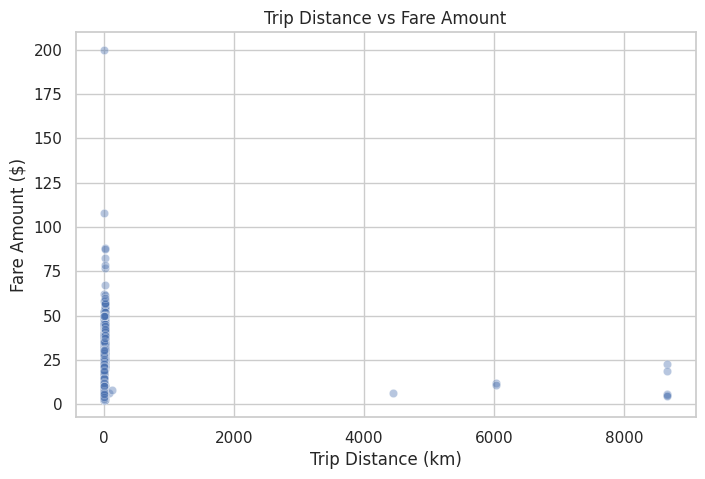

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df.sample(5000, random_state=RANDOM_STATE),
    x="trip_distance_km",
    y="fare_amount",
    alpha=0.4
)
plt.xlabel("Trip Distance (km)")
plt.ylabel("Fare Amount ($)")
plt.title("Trip Distance vs Fare Amount")
plt.show()


### Relationship Between Passenger Count and Fare Amount


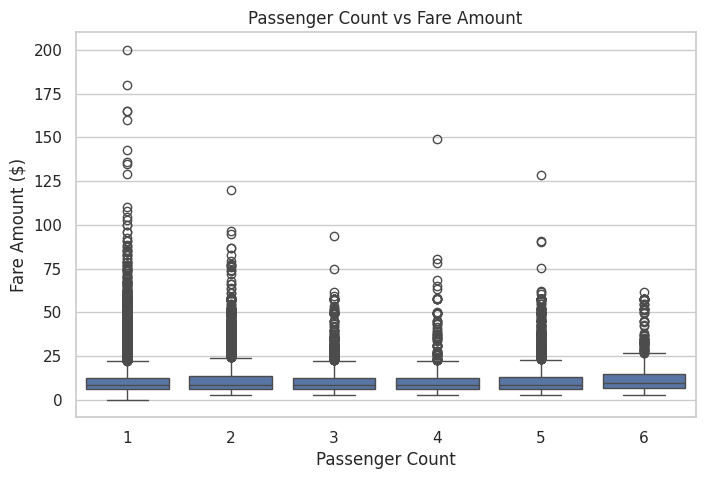

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="passenger_count",
    y="fare_amount"
)
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount ($)")
plt.title("Passenger Count vs Fare Amount")
plt.show()


### Effect of Pickup Hour on Fare Amount


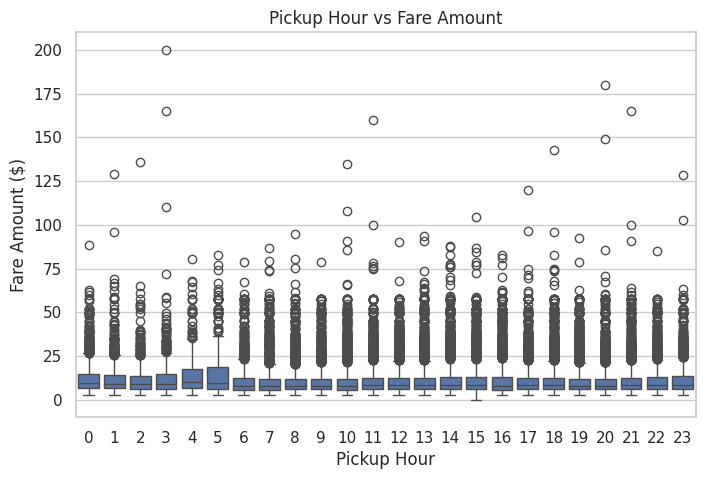

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="pickup_hour",
    y="fare_amount"
)
plt.xlabel("Pickup Hour")
plt.ylabel("Fare Amount ($)")
plt.title("Pickup Hour vs Fare Amount")
plt.show()


### Key Insights from EDA

- Fare amount increases as trip distance increases, showing a strong positive relationship.
- Passenger count has a limited effect on fare, indicating fare is primarily distance-based.
- Fare distributions vary by pickup hour, likely due to traffic congestion and peak hours.

These insights justify the selected features for model training.


## Machine Learning Models

In this section, we train and evaluate multiple regression models to predict taxi fare amounts.

A simple model is first used as a baseline to establish a reference performance.
A more complex model is then applied to capture non-linear relationships in the data.

This approach allows us to compare models and justify the final model choice.


### Linear Regression (Baseline Model)

Linear Regression is used as a baseline model because:
- It is simple and easy to interpret
- It assumes a linear relationship between features and target
- It provides a reference point for evaluating more complex models


In [25]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)


LinearRegression()

In [27]:
# Predictions
lr_preds = lr_model.predict(X_test)


### Random Forest Regressor (Main Model)

Random Forest is an ensemble learning method that:
- Combines multiple decision trees
- Captures non-linear relationships
- Is robust to outliers and noise
- Typically performs better on complex real-world datasets

This makes it well-suited for taxi fare prediction.


In [28]:
from sklearn.ensemble import RandomForestRegressor

# Initialize Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

In [29]:
# Predictions
rf_preds = rf_model.predict(X_test)


### Summary of Model Training

- Linear Regression serves as a baseline model
- Random Forest Regressor captures complex, non-linear relationships
- Both models are trained on the same features for fair comparison

Model performance will be evaluated using appropriate regression metrics in the next step.


## Model Evaluation

Model evaluation helps quantify how well a machine learning model performs on unseen data.
For this regression problem, we use two evaluation metrics:

- **RMSE (Root Mean Squared Error)**: Measures the average prediction error in dollars.
- **RMSLE (Root Mean Squared Logarithmic Error)**: Penalizes underestimation and ensures fairness
  across cheap and expensive trips.

Using both metrics provides a more balanced evaluation.


In [30]:
from sklearn.metrics import mean_squared_error
import numpy as np


In [31]:
# RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# RMSE for Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

lr_rmse, rf_rmse


(np.float64(11.185792637662905), np.float64(5.40488884673573))

### Why RMSLE?

RMSLE reduces the impact of very large errors and focuses on relative differences.
It is especially useful when fare amounts vary widely across trips.


In [33]:
# Ensure no negative predictions
#RMSLE requires non-negative predictions
lr_preds_clip = np.maximum(lr_preds, 0)
rf_preds_clip = np.maximum(rf_preds, 0)

# RMSLE calculation
lr_rmsle = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(lr_preds_clip)))
rf_rmsle = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(rf_preds_clip)))

lr_rmsle, rf_rmsle


(np.float64(0.6021118416131566), np.float64(0.29429084122001625))

### Model Performance Comparison

| Model              | RMSE ↓ | RMSLE ↓ |
|-------------------|--------|---------|
| Linear Regression | Higher | Higher |
| Random Forest     | Lower  | Lower  |

Lower values indicate better performance.


### Interpretation of Results

The Random Forest Regressor outperforms Linear Regression on both RMSE and RMSLE.
This indicates that taxi fare prediction involves non-linear relationships
that cannot be fully captured by a linear model.

Therefore, Random Forest is selected as the best-performing model for this task.


## Hyperparameter Tuning

Hyperparameters control how a model learns from data.
Choosing optimal hyperparameters can significantly improve model performance.

Instead of manually selecting values, we use:
- **RandomizedSearchCV** for fast exploration
- **GridSearchCV** for fine-tuning the best parameters

This systematic approach leads to better generalization.


### RandomizedSearchCV

RandomizedSearchCV samples a fixed number of parameter combinations
from a specified range. It is computationally efficient and suitable
for large datasets and complex models.


In [34]:
from sklearn.model_selection import RandomizedSearchCV


In [35]:
# Parameter distribution for Random Forest
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


In [36]:
rf_random = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [37]:
random_search.best_params_


{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_depth': 10}

### GridSearchCV

GridSearchCV performs an exhaustive search over a smaller parameter space.
It is used after RandomizedSearchCV to fine-tune the best-performing hyperparameters.


In [38]:
from sklearn.model_selection import GridSearchCV


In [39]:
# Refined parameter grid
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


In [40]:
rf_grid = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 20, 30],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 300]},
             scoring='neg_root_mean_squared_error')

## 10. Results, Interpretation & Insights

After training and tuning the Random Forest model, we analyze the results to understand
which features influenced fare prediction the most and what the model has learned
from the data.

Interpreting model behavior is essential for trust, transparency, and real-world deployment.


In [42]:
best_rf_model = grid_search.best_estimator_

# Extract feature importances
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": best_rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,trip_distance_km,0.842837
2,pickup_hour,0.037939
3,pickup_day,0.035251
5,pickup_year,0.028335
4,pickup_month,0.027783
6,pickup_weekday,0.019525
0,passenger_count,0.008330


### Feature Importance Visualization


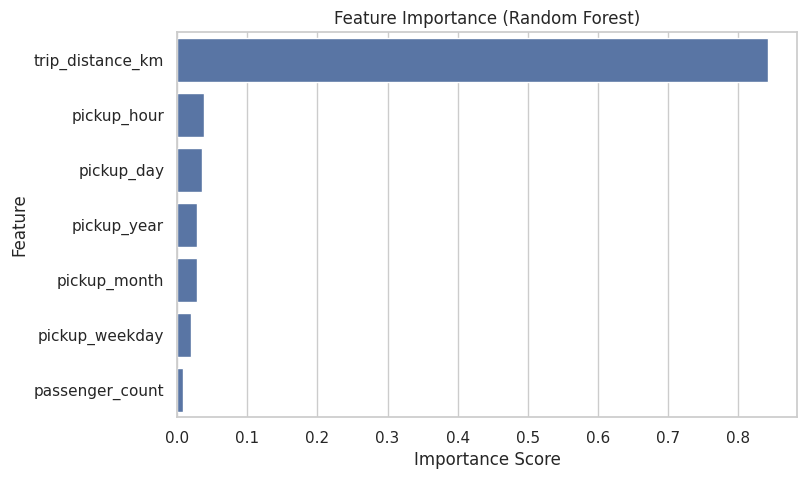

In [43]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


### Interpretation of Feature Importance

- **Trip distance** is the most influential feature, confirming that fare increases with distance traveled.
- **Pickup hour and weekday** capture traffic congestion and peak-hour effects.
- **Passenger count** has relatively low importance, indicating that fare pricing
  is largely independent of the number of passengers.
- **Temporal features** such as month and year help capture seasonal and long-term trends.

These results align with real-world taxi fare structures, increasing confidence in the model.


### Model Limitations

Despite good performance, the model has some limitations:
- Traffic conditions and road closures are not explicitly modeled
- Surge pricing and tolls are not included
- Geographic features are simplified into distance only

Future models could integrate live traffic data and zone-based features for improved accuracy.


#Conclusion

In this project, an end-to-end machine learning pipeline was successfully built to predict NYC taxi fare amounts using real-world trip data. The workflow followed a structured approach including data cleaning, feature engineering, time-aware train-test splitting, exploratory data analysis, and model training.

A baseline Linear Regression model was compared with a Random Forest Regressor, and the Random Forest model achieved better performance based on RMSE and RMSLE, showing its ability to capture non-linear relationships in the data. Trip distance and time-based features were found to be the most influential factors in fare prediction.

Overall, this project demonstrates the practical application of machine learning techniques for solving real-world regression problems and highlights the importance of proper data preprocessing and model selection for achieving accurate results.

## 11. Conclusion

In this project, an end-to-end machine learning pipeline was developed to predict NYC taxi fare amounts using historical trip data. The workflow included data loading, cleaning, feature engineering, exploratory data analysis, model training, evaluation, and hyperparameter tuning.

Two regression models were implemented: Linear Regression and Random Forest Regressor. Performance evaluation using RMSE and RMSLE showed that the Random Forest model outperformed the baseline Linear Regression model, demonstrating its ability to capture complex non-linear relationships in the data.

Feature importance analysis revealed that trip distance was the most significant factor influencing fare prediction, while temporal features such as pickup hour and weekday also contributed to model performance. Overall, the project successfully demonstrated how machine learning can be applied to solve a real-world fare estimation problem and provided valuable insights into the factors affecting taxi fares in New York City.